quick todo
- swap to crossval for validations (more time)
- drop the delta features (easiest)

In [ ]:
#dependencies
import numpy
import pandas as pd
import os
from google.colab import drive
from sklearn.metrics import mean_absolute_error,accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV

In [ ]:
#training_data = pd.read_csv("https://docs.google.com/spreadsheets/d/1EiQme3CrCxkUkwiMQ1yiSc0PMXpXrxxPaArIGyTjWN4/export?format=csv")
#training_data = training_data.dropna(subset=['red_win'])  # drop the 15 incomplete rows
#training_data['red_win'] = training_data['red_win'].astype(int)
aldine = pd.read_csv("https://docs.google.com/spreadsheets/d/1EiQme3CrCxkUkwiMQ1yiSc0PMXpXrxxPaArIGyTjWN4/export?format=csv")
space_city = pd.read_csv("https://docs.google.com/spreadsheets/d/1R_KcdFCqDEAyJrdhHeT0llA2Ve3Npec6mQ6s_auNWy4/export?format=csv")

training_data = pd.concat([aldine, space_city], ignore_index=True)
training_data = training_data.dropna(subset=['red_win'])
training_data['red_win'] = training_data['red_win'].astype(int)

In [ ]:
y = training_data.red_win
features = ['red_climb_l2_count','red_climb_l1_count', 'red_auto_count', 'red_auto_align_sum','red_depot_sum', 'red_outpost_sum', 'red_under_trench_sum','red_over_bump_sum', 'red_fuel_scorer_count', 'red_driver_hours_sum',
       'red_driver_hours_max', 'red_build_quality_mean',
       'blue_climb_l2_count', 'blue_climb_l1_count', 'blue_auto_count',
       'blue_auto_align_sum', 'blue_depot_sum', 'blue_outpost_sum',
       'blue_under_trench_sum', 'blue_over_bump_sum', 'blue_fuel_scorer_count',
       'blue_driver_hours_sum', 'blue_driver_hours_max',
       'blue_build_quality_mean']
X = training_data[features]
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)
base_model = DecisionTreeClassifier(random_state=1)
base_model.fit(train_X, train_y)
win_predictions = base_model.predict(val_X)
val_accuracy = accuracy_score(win_predictions, val_y)
print(win_predictions)
print("\n")
print(val_accuracy)



[0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 0 0 1 0 1]


0.6774193548387096


In [ ]:
def get_accuracy(max_leaf_nodes, train_X, val_X, train_y, val_y):
    model = DecisionTreeClassifier(max_leaf_nodes=max_leaf_nodes, random_state=0)
    model.fit(train_X, train_y)
    preds_val = model.predict(val_X)
    val_accuracy = accuracy_score(val_y, preds_val)
    return(val_accuracy)

In [ ]:
import numpy
candidate_max_leaf_nodes = [2, 3, 4, 5, 6, 8, 10] #swap to smaller since our dataset is very cute and petite
candidate_scores = []
for max_leaf_nodes in candidate_max_leaf_nodes:
    accuracy = get_accuracy(max_leaf_nodes, train_X, val_X, train_y, val_y)
    print(f"max leaf nodes: {max_leaf_nodes}\n"+f"accuracy: {accuracy}")
    candidate_scores.append(accuracy)


max leaf nodes: 2
accuracy: 0.5161290322580645
max leaf nodes: 3
accuracy: 0.5806451612903226
max leaf nodes: 4
accuracy: 0.6451612903225806
max leaf nodes: 5
accuracy: 0.6451612903225806
max leaf nodes: 6
accuracy: 0.5161290322580645
max leaf nodes: 8
accuracy: 0.6774193548387096
max leaf nodes: 10
accuracy: 0.6451612903225806


(old) 5 leaf nodes is optimal

In [ ]:
param_grid = {
    'max_leaf_nodes': [2, 3, 4, 5, 6, 8, 10],
    'max_depth': [1, 2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X, y)
print(grid_search.best_params_)
print(f"best cv f1: {grid_search.best_score_:.3f}")

final_model = grid_search.best_estimator_

{'class_weight': 'balanced', 'max_depth': 2, 'max_leaf_nodes': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
best cv f1: 0.612


In [ ]:
#final_model = DecisionTreeClassifier(max_leaf_nodes=5,random_state=0)
#final_model.fit(X, y)

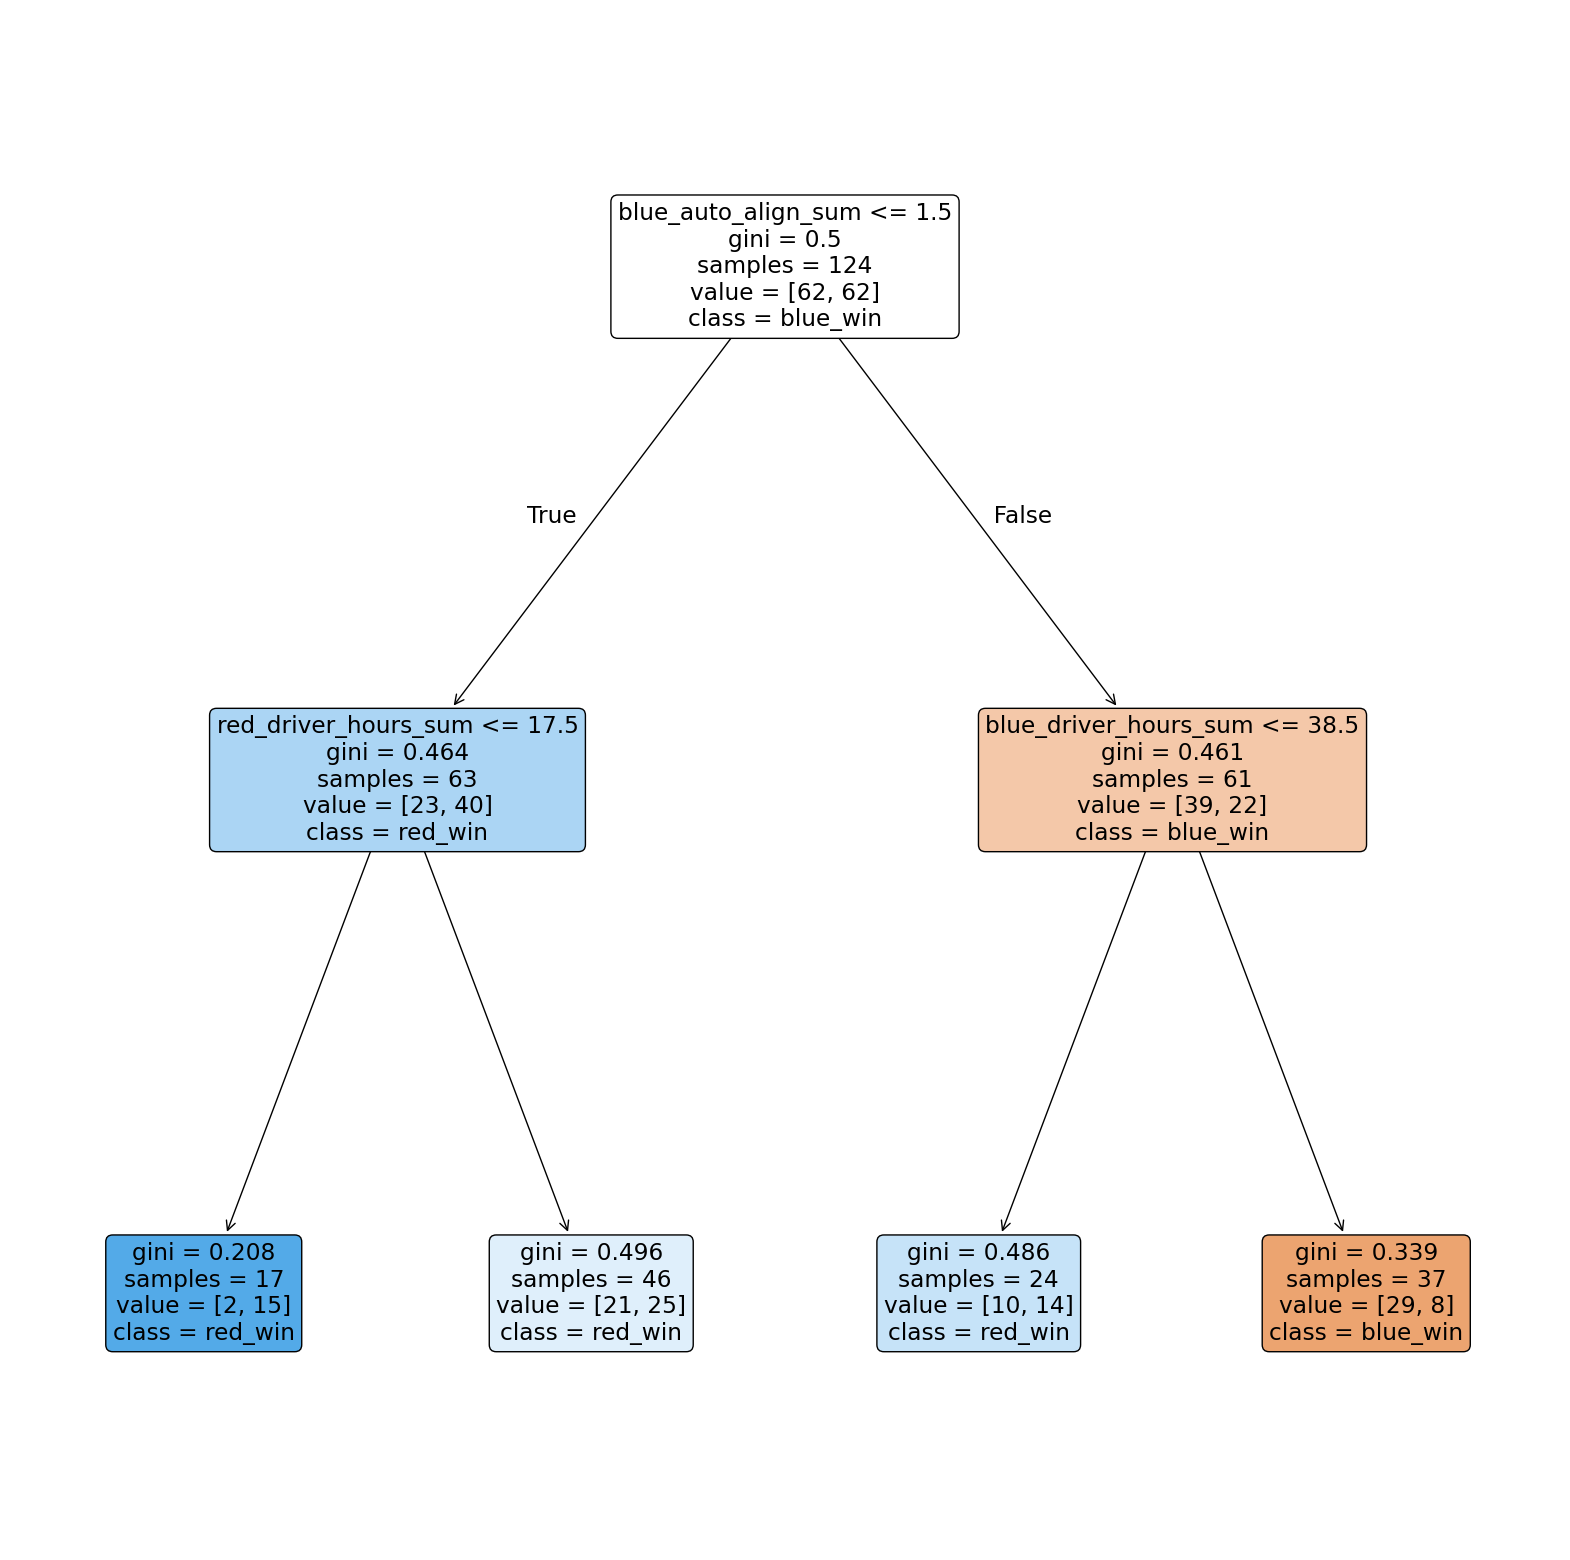

In [ ]:
plt.figure(figsize=(20, 20))
plot_tree(final_model, feature_names=features, class_names=['blue_win', 'red_win'], filled=True, rounded=True)
plt.savefig('tree.png', dpi=150, bbox_inches='tight')
plt.show()

final model trained on Aldine data; test with space city data



In [ ]:
validation_data = pd.read_csv("https://docs.google.com/spreadsheets/d/1R_KcdFCqDEAyJrdhHeT0llA2Ve3Npec6mQ6s_auNWy4/export?format=csv")
validation_key = validation_data
#print(validation_data.columns)
validation_y=validation_data.red_win

validation_data = validation_data.drop(columns=['red_win','match','delta_climb_l3_any', 'delta_climb_l2_count',
       'delta_climb_l1_count', 'delta_auto_count', 'delta_auto_align_sum',"blue_climb_l3_any","red_climb_l3_any",
       'delta_depot_sum', 'delta_outpost_sum', 'delta_under_trench_sum',
       'delta_over_bump_sum', 'delta_fuel_scorer_count',
       'delta_driver_hours_sum', 'delta_driver_hours_max',
       'delta_build_quality_mean'])
validation_predictions = final_model.predict(validation_data)
final_accuracy = accuracy_score(validation_predictions, validation_y)
print(f"{round((final_accuracy*100))}% accuracy on space city after being trained on aldine data!!")

69% accuracy on space city after being trained on aldine data!!
